In [26]:
import numpy as np
import porespy as ps
import matplotlib.pyplot as plt
import tifffile as tif
import cv2
from skimage.morphology import skeletonize
import scipy.ndimage as ndi
from skimage import measure
from skimage import morphology as mph
from skimage.color import label2rgb
import pandas as pd

In [27]:
def find_intersectikon(skeleton):
    selems = list()
    selems.append(np.array([[0, 1, 0], [1, 1, 1], [0, 0, 0]]))
    selems.append(np.array([[1, 0, 1], [0, 1, 0], [1, 0, 0]]))
    selems.append(np.array([[1, 0, 1], [0, 1, 0], [0, 1, 0]]))
    selems.append(np.array([[0, 1, 0], [1, 1, 0], [0, 0, 1]]))
    selems.append(np.array([[0, 0, 1], [1, 1, 1], [0, 1, 0]]))
    selems = [np.rot90(selems[i], k=j) for i in range(5) for j in range(4)]
    selems.append(np.array([[0, 1, 0], [1, 1, 1], [0, 1, 0]]))
    selems.append(np.array([[1, 0, 1], [0, 1, 0], [1, 0, 1]]))
    branches = np.zeros_like(skeleton, dtype=bool)
    for selem in selems:
        branches |= ndi.binary_hit_or_miss(skeleton, selem)
    return branches

In [28]:
def crack_skeletonize(crack):
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT,(50,50))
    dilated= cv2.dilate(crack,kernel,iterations=1)
    ske=skeletonize(np.where(dilated!=0,1,0))
    return ske

In [29]:
def get_indecrack(ske,branches):
    kernel_j = cv2.getStructuringElement(cv2.MORPH_RECT,(3,3))
    bra=cv2.dilate(branches.astype('uint8'),kernel_j)
    cracksonly=np.where(ske!=0,255,0)
    cracksonly=np.where(bra!=0,0,cracksonly)
    return cracksonly

In [30]:
def meausure_thickness(img,reso):
    thk=ps.filters.local_thickness(img,sizes=np.arange(0,60,1))
    psd=ps.metrics.pore_size_distribution(thk,voxel_size=reso,log=False)
    return thk,psd

In [42]:
def measure_length(skelet):
    length_label=measure.label(skelet)
    prop_table=measure.regionprops_table(length_label, properties=('label','centroid','area'))
    prop = measure.regionprops(length_label)
    im_length=props_to_image(prop, length_label.shape, 'area')
    return prop_table,im_length

In [53]:
def denoise_skeletonize(crack):
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT,(10,10))
    dilated= cv2.dilate(crack,kernel,iterations=1)
    eroded=cv2.erode(dilated,kernel,iterations=1)
    ske=(skeletonize(np.where(dilated!=0,1,0))).astype('uint8')
    return (255*ske)

In [44]:
""""
properties to image
"""""
import porespy as ps
def props_to_image(regionprops, shape, prop):
    im = np.zeros(shape=shape)
    for r in regionprops:
        if prop == 'convex':
            mask = r.convex_image
        else:
            mask = r.image
        temp = mask * r[prop]
        s = ps.tools.bbox_to_slices(r.bbox)
        im[s] += temp
    return im


Read image and parameters

In [49]:
im=tif.imread('/Downloads/Demo/Segmentation/Void_crk/manual_proc/L231_U1_Simple Segmentation_ck_dn.tif')

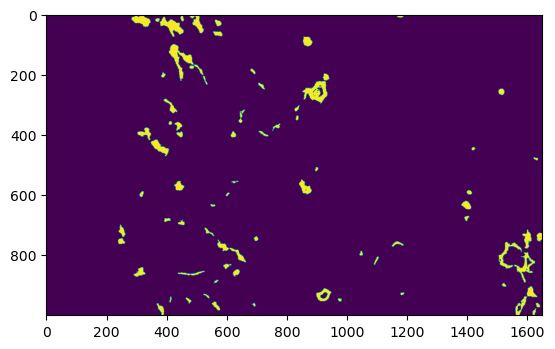

In [50]:
plt.imshow(im)

Measure the thickness and distribution of cracks after manual segmentation

In [51]:
resolution=20
thk,psd=meausure_thickness(im,resolution)   # input resolution in um/px
width_s=np.array(thk)*resolution
crack_area=np.count_nonzero(im)*(resolution**2)/1000000

  0%|          | 0/60 [00:00<?, ?it/s]

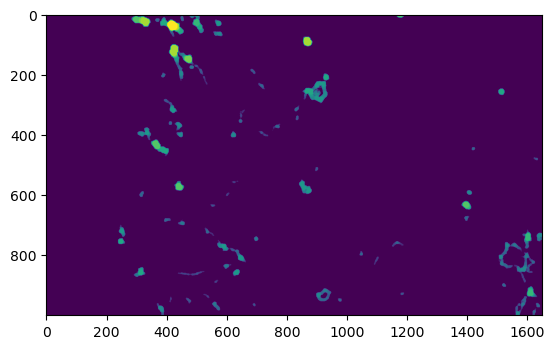

In [52]:
plt.imshow(thk)

<BarContainer object of 10 artists>

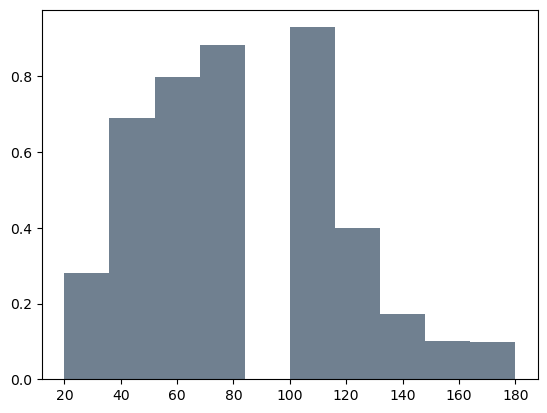

In [33]:

plt.bar(psd.bin_centers,(np.array(psd.satn)*crack_area),psd.bin_widths,color='slategray')

In [ ]:
#Calculate length distribution 

In [61]:
"""""
plot length distribution
"""
skele=denoise_skeletonize(im)
table,img_l=measure_length(skele.astype('uint8'))
length__true=np.array(img_l*resolution)


Text(0.5, 0, 'length(um)')

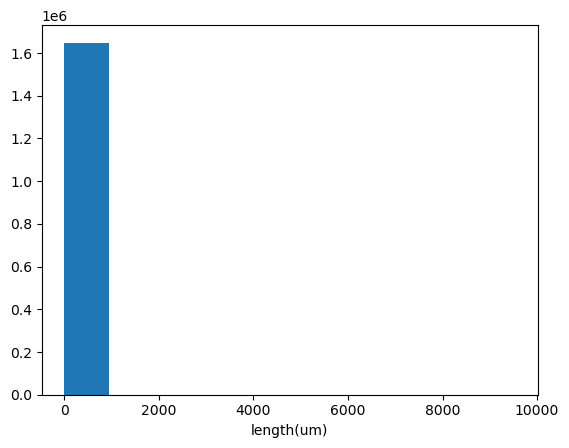

In [65]:
plt.hist(length__true.flatten())
plt.xlabel('length(um)')